number of pulsars 2014


/tmp/ipykernel_786/3724504319.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Dark2')   # or 'tab10', 'Set1', 'Paired', etc.


Done in 2.0s for a (10%)
Done in 3.3s for b (20%)
Done in 4.7s for c (30%)
Done in 6.0s for d (40%)


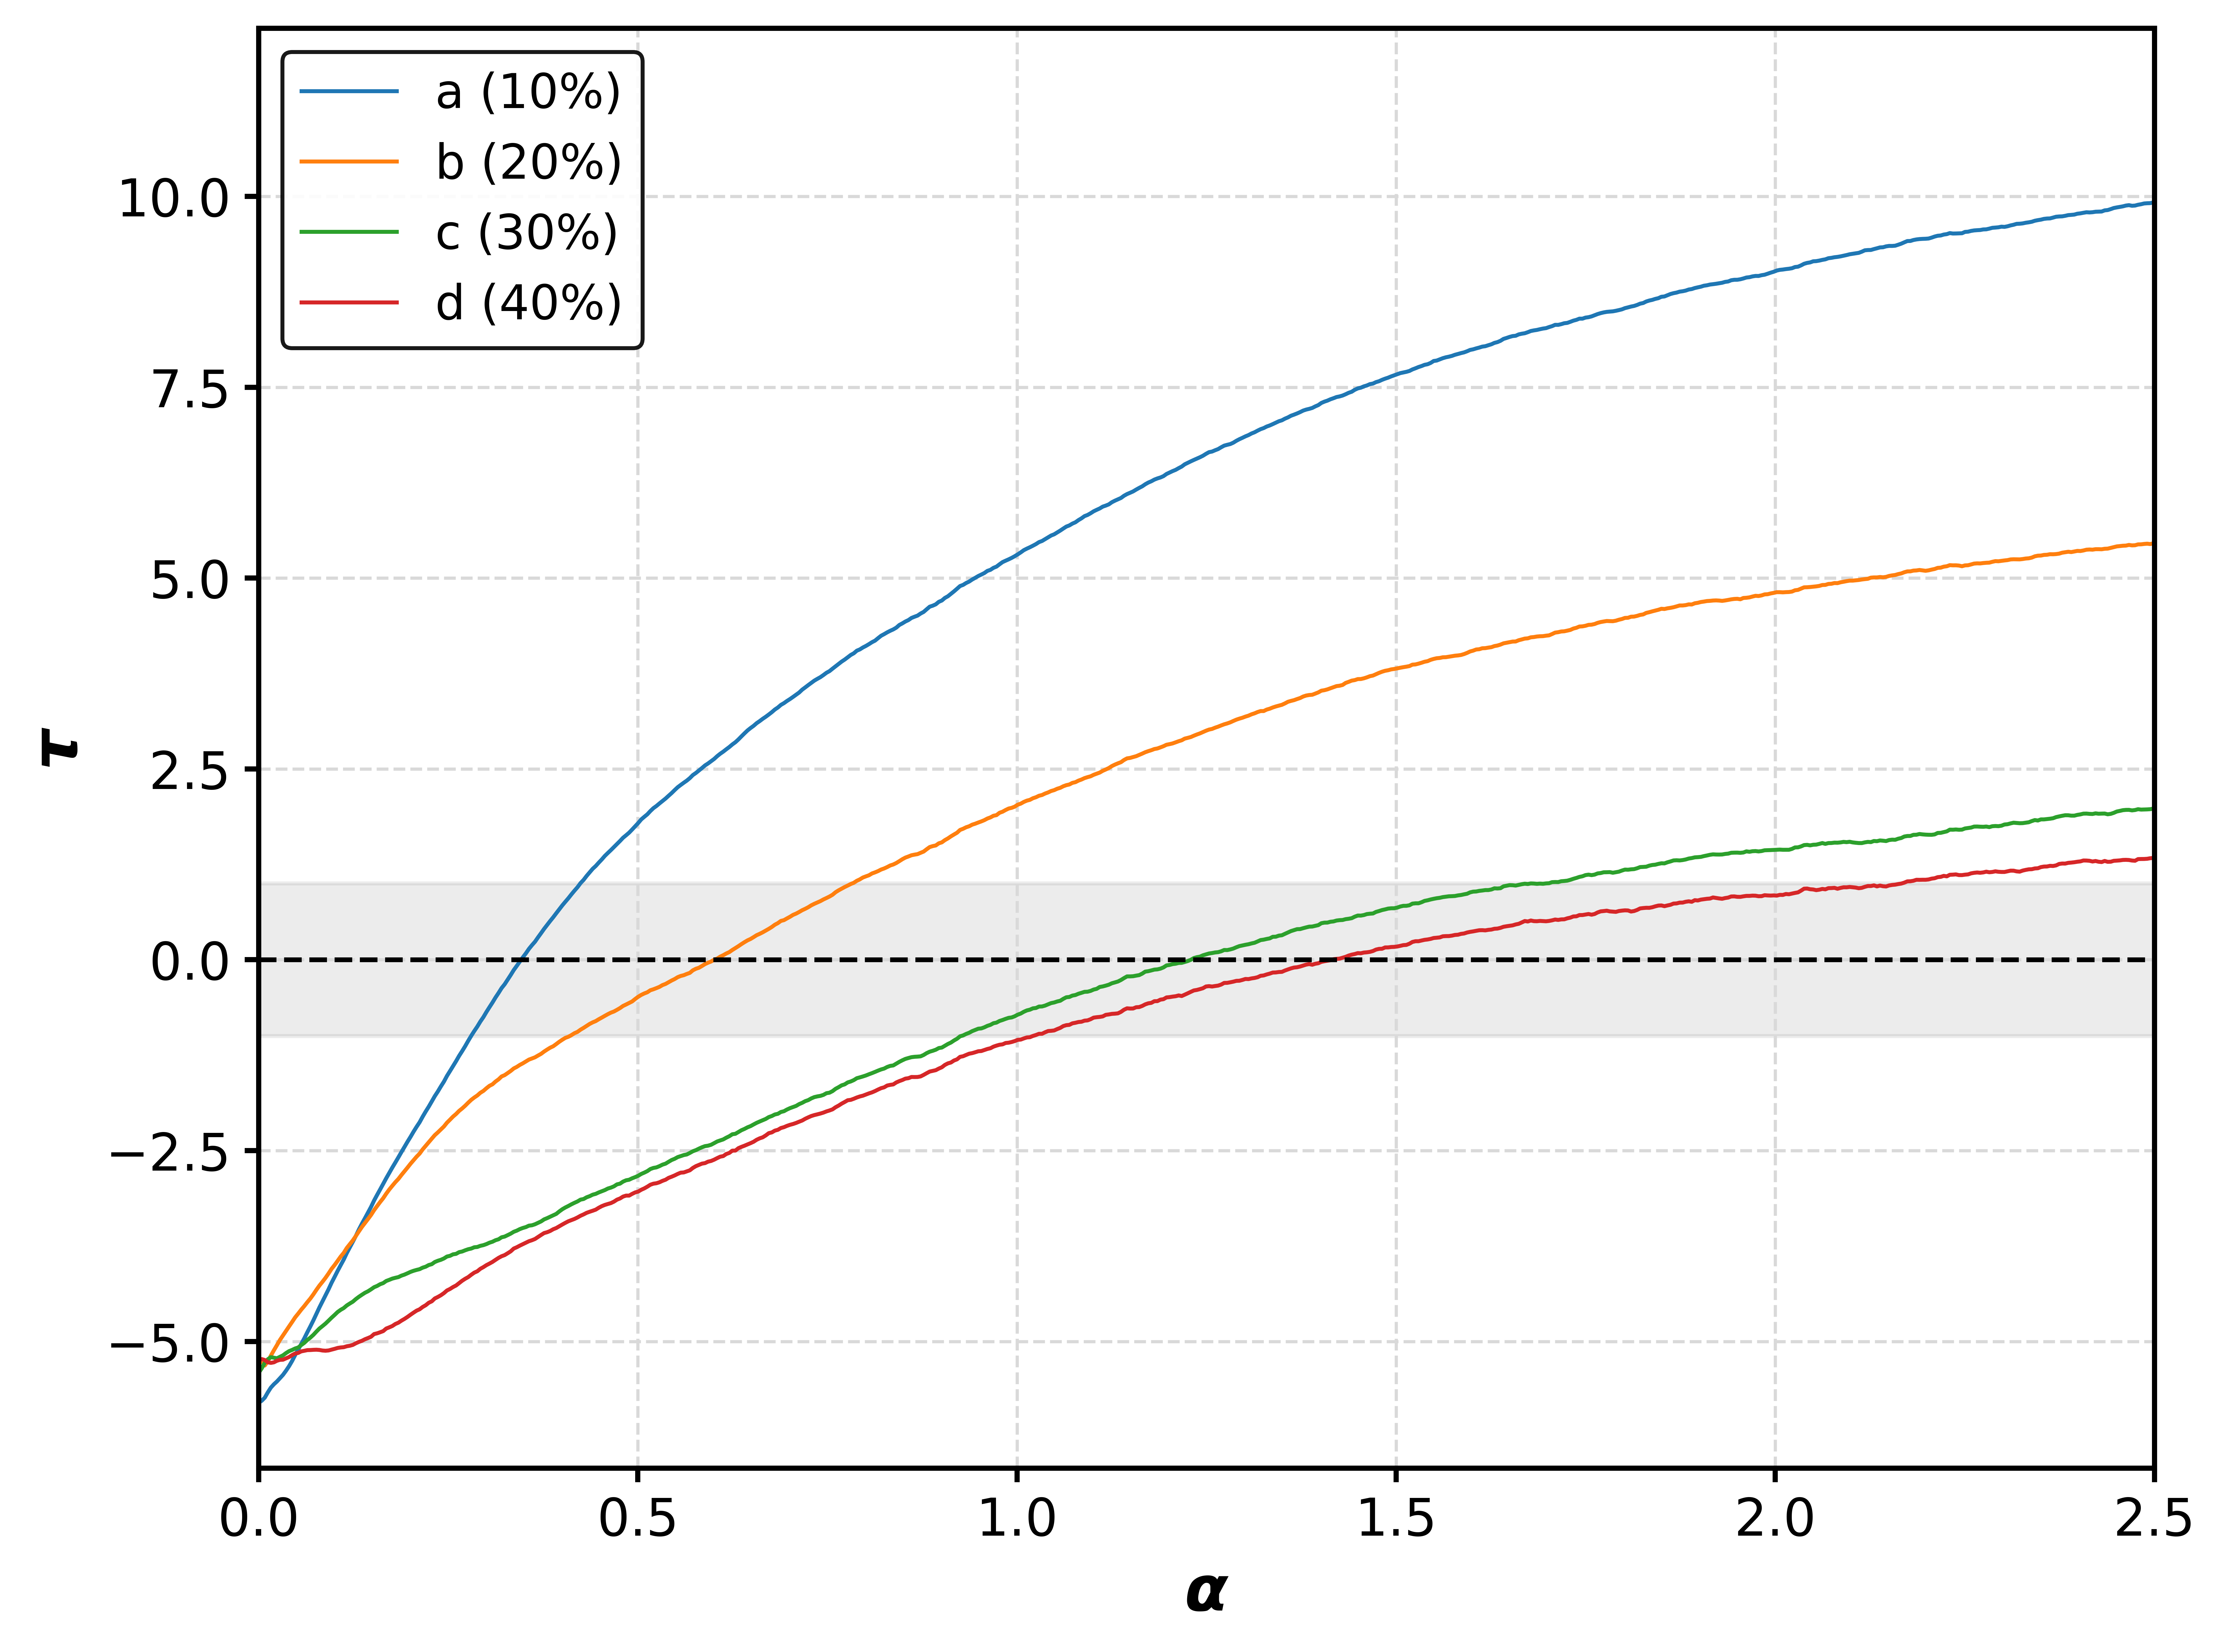

In [2]:
#please provide necessary paths

#change snr to test for different cases 
%reset -f
%matplotlib inline
from psrpoppy import population
import pickle
from matplotlib.cm import get_cmap
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import sys
sys.path.append('path to psrpoppy')

import matplotlib as mpl

#GLOBAL STYLE SETTINGS
mpl.rcParams.update({
    "font.size": 14,                
    "axes.labelweight": "bold",    
    "axes.titlesize": 16,          
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,          
    "lines.linewidth": 1,
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})


sys.modules['population'] = real_population
filename='PMSURV.results'


#df_smr = pd.read_excel("/home/sanjith/PsrPopPy/df_smr.xlsx")


with open(filename, 'rb') as f:
    pop = pickle.load(f)

fluxes = np.array([psr.s_1400() for psr in pop.population])*1e-26
distances = np.array([psr.dtrue for psr in pop.population])*1e3
snr=np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)


df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})
 
#df=df[df["snr"] >= 9]          #change snr to test for different cases                                                           
"""
df = pd.concat([df, df_smr], ignore_index=True) #adding smeared pulsars  to the dataset

flux_cut=10**((-2-1.734)/1.06)
print("log_flux_cut",np.log10(flux_cut))
"""




df['Flux_log'] = np.log10(df['Flux'])
df['Dist_log'] = np.log10(df['Distance'])

def compute_LogLth(D_array, flux_thresh, alpha):
    """Compute log10(flux_thresh * D^alpha)"""
    return np.log10(flux_thresh) + alpha * np.log10(D_array)

@njit
def compute_tau_numba(D_logs, Lprime_logs, thresh, alpha):
    n = len(D_logs)
    N_a = np.zeros(n, dtype=np.int64)
    R_a = np.zeros(n, dtype=np.int64)
    E_a = np.zeros(n)
    V_a = np.zeros(n)
    
    for i in range(n):
        Di = D_logs[i]
        Li = Lprime_logs[i]
        L_thi = np.log10(thresh * (10 ** Di) ** alpha)
        N_count = 0
        R_count = 0
        for j in range(n):
            D = D_logs[j]
            L = Lprime_logs[j]
            if (D <= Di) and (L >= L_thi):
                N_count += 1
                if Li >= L:
                    R_count += 1
        N_a[i] = N_count
        R_a[i] = R_count
        E_a[i] = 0.5 * (N_count + 1)
        V_a[i] = (N_count ** 2 - 1) / 12 if N_count > 0 else 0.0  #N_count is becoming negative 



    numerator = np.sum(R_a - E_a)
    denominator = np.sqrt(np.sum(V_a))
    return numerator / denominator if denominator != 0 else np.nan

def compute_tau_for_alpha(alpha_thresh):
    alpha, thresh = alpha_thresh

   
    LogLthA = compute_LogLth(df['Distance'].values, thresh, alpha)

   
    Lprime_Log = df['Flux_log'].values + alpha * df['Dist_log'].values

    # Applying detection threshold
    mask = Lprime_Log >= LogLthA
    D_logs = df['Dist_log'].values[mask]
    Lprime_logs = Lprime_Log[mask]

    if len(D_logs) == 0:
        return alpha, np.nan

    tau = compute_tau_numba(D_logs, Lprime_logs, thresh, alpha)
    return alpha, tau

if __name__ == '__main__':

    
    alphas = np.linspace(0,4,1000)
    percentiles = [10, 20, 30, 40]  # percentage of faintest sources to discard
    flux_thresholds = np.percentile(df["Flux"], percentiles)

    labels = ['a (10%)', 'b (20%)', 'c (30%)', 'd (40%)']
    start = time.time()

    plt.figure(figsize=(8,6),dpi=1000)
    cmap = get_cmap('Dark2')
    colors = [cmap(i) for i in range(len(labels))]
    for label, thresh in zip(labels, flux_thresholds):
        alpha_thresh_list = [(alpha, thresh) for alpha in alphas]
        with multiprocessing.Pool(processes=4) as pool:
            results = pool.map(compute_tau_for_alpha, alpha_thresh_list)

        results.sort()
        taus = [tau for alpha, tau in results]
        print(f"Done in {time.time() - start:.1f}s for {label}")
        plt.plot(alphas, taus, label=f"{label}", linewidth=1)



plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.fill_between(alphas, -1, 1, color='gray', alpha=0.15)
plt.xlabel(r'$\boldsymbol{\alpha}$', fontsize=16) 
plt.ylabel(r'$\boldsymbol{\tau}$', fontsize=16)


plt.legend(frameon=True, loc="best", facecolor='white', framealpha=0.9, edgecolor='black')
plt.savefig("path/efron_petrosian_tau_alpha_no smeared_snr_9_lfl06_deafult_new.pdf", dpi=1000, bbox_inches="tight")
plt.tight_layout()
plt.show()

